# Prédire l'arrivée des oiseaux migrateurs dans le Nord-Pas-de-Calais

### Notebook de soutenance — projet RNCP « Concepteur Développeur en Science des Données »

---

**Ce document explique, du début à la fin et sans jargon inutile, un projet de science des données.**
Il est écrit pour être compris par un jury qui ne code pas et ne connaît pas l'informatique. Chaque
morceau de code est précédé d'un texte qui dit **pourquoi** on le fait et **comment** ça marche, et
suivi d'un texte qui explique **ce que le résultat veut dire**.

Toutes les cellules de code de ce notebook sont réelles : elles utilisent les fichiers de données et
les modèles effectivement produits par le projet (pas des exemples inventés). En les exécutant, on
retrouve les chiffres annoncés — c'est ce qui permet de **valider** chaque bloc devant le jury.

**Région étudiée :** Nord-Pas-de-Calais &nbsp;|&nbsp; **Année :** 2026

## Comment lire ce notebook

Le référentiel RNCP visé est découpé en **6 blocs de compétences (BC01 à BC06)**. Ce notebook suit
exactement ce découpage : une partie = un bloc = une compétence à démontrer devant le jury.

| Partie | Bloc RNCP | Question à laquelle il répond |
|---|---|---|
| 1 | **BC01** — Infrastructure de données | D'où viennent les données, et comment les rend-on utilisables ? |
| 2 | **BC02** — Analyse exploratoire | Que nous apprennent les données avant tout calcul savant ? |
| 3 | **BC03** — Machine Learning | Peut-on prédire la présence d'un oiseau, et avec quelle fiabilité ? |
| 4 | **BC04** — Deep Learning | Qu'apporterait une IA plus complexe, et pourquoi ne l'a-t-on pas fait ? |
| 5 | **BC05** — Industrialisation | Comment rendre le modèle utilisable par quelqu'un qui ne code pas ? |
| 6 | **BC06** — Gestion de projet | Comment le projet a-t-il été piloté, testé, documenté ? |

Un **glossaire** de tous les termes techniques utilisés se trouve à la toute fin du notebook — n'hésitez
pas à vous y référer à tout moment (mots comme *API*, *pipeline*, *jeu d'entraînement*, etc. sont
expliqués là-bas, en plus d'être expliqués la première fois qu'ils apparaissent).

Chaque partie se termine par un encadré **« Ce qu'il faut retenir »** qui résume en 3-4 phrases simples
ce qui vient d'être montré : c'est la version courte à donner si le jury est pressé.

## Le problème, en une phrase

**Peut-on deviner, à partir de la date et de la météo du jour, si une espèce d'oiseau migrateur donnée
a des chances d'être présente dans le Nord-Pas-de-Calais ?**

### Pourquoi c'est utile

- **Associations de protection de la nature et observatoires ornithologiques** : mieux anticiper les
  pics d'arrivée pour organiser des comptages, des sorties nature, des mesures de protection.
- **Science citoyenne** : les applications grand public d'observation d'oiseaux profitent de
  prédictions pour orienter les utilisateurs vers les bonnes périodes et les bons lieux.
- **Pédagogie / sensibilisation** : un outil simple qui donne une probabilité de présence est plus
  parlant qu'un tableau de statistiques pour expliquer la migration au grand public.

### La question scientifique sous-jacente

Les oiseaux migrateurs partent et reviennent chaque année à des périodes assez régulières, mais la
date exacte varie d'une année sur l'autre. Une hypothèse courante chez les ornithologues est que ce
déclenchement est en partie lié aux conditions climatiques. Ce projet met cette hypothèse à l'épreuve
avec des données réelles et des méthodes statistiques / d'intelligence artificielle, pour la région
Nord-Pas-de-Calais et 4 espèces choisies pour leurs profils de migration différents.

## Avant de commencer : préparation technique

La cellule ci-dessous ne contient rien de conceptuel : elle prépare seulement l'environnement de travail
(elle indique à Python où se trouve le projet, importe les outils nécessaires, et règle l'apparence des
graphiques). On peut l'exécuter sans s'y attarder — **c'est la seule cellule « de service » du notebook.**

In [1]:
import sys
from pathlib import Path

# On localise la racine du projet, que ce notebook soit lancé depuis le
# dossier "notebooks/" ou depuis la racine du projet.
RACINE = Path.cwd()
if RACINE.name == "notebooks":
    RACINE = RACINE.parent
if not (RACINE / "scripts").exists():
    RACINE = Path.cwd()

for chemin in (RACINE / "scripts", RACINE, RACINE / "api"):
    if str(chemin) not in sys.path:
        sys.path.insert(0, str(chemin))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline

print(f"Racine du projet détectée : {RACINE}")
print("Environnement prêt.")

Racine du projet détectée : C:\Users\rasmi\Projects\projet_rncp\oiseaux_migrateurs_npdc
Environnement prêt.


---
# Partie 1 — BC01 : Construire une infrastructure de données

**Ce que ce bloc doit démontrer :** être capable d'aller chercher des données dans le monde réel, de
les stocker, de les nettoyer et de les organiser pour qu'elles deviennent exploitables.

Avant de faire de l'intelligence artificielle, il faut d'abord réunir la matière première. C'est
comparable à un cuisinier qui va au marché acheter ses ingrédients, les lave et les épluche avant de
commencer à cuisiner : si les ingrédients sont mauvais ou mal préparés, le plat sera raté, quel que
soit le talent du cuisinier ensuite. En science des données, cette étape de préparation représente
souvent la majorité du temps de travail réel d'un projet — bien avant l'intelligence artificielle
elle-même.

## 1.1 D'où viennent les données ?

Le projet combine **deux sources de données publiques et gratuites**, interrogées automatiquement par
un programme (on parle d'appeler une **API** — un guichet informatique par lequel un site met ses
données à disposition d'autres programmes, sans passer par un site web classique).

| Source | Ce que c'est | Ce qu'on y récupère |
|---|---|---|
| **GBIF** (*Global Biodiversity Information Facility*) | Une base de données mondiale et publique qui centralise des millions d'observations d'espèces animales et végétales, transmises par des musées, des instituts scientifiques et des naturalistes amateurs (un peu comme une encyclopédie collaborative, mais pour la biodiversité observée sur le terrain). | Pour chaque observation d'oiseau : l'espèce, la date, et l'endroit exact (latitude/longitude) où elle a été vue. |
| **Open-Meteo** | Une archive météorologique historique gratuite, qui reconstitue la météo passée pour n'importe quel point du globe à partir de modèles météorologiques. | Pour chaque jour depuis 2015 : températures, pluie, vent, humidité, pression atmosphérique. |

### La zone d'étude

Le projet se concentre sur le **Nord-Pas-de-Calais**, délimité par un simple rectangle de coordonnées
GPS (une *bounding box*). Tout ce rectangle est visualisé ci-dessous pour rendre concrètes les
coordonnées utilisées dans le code.

In [2]:
from config import ESPECES, ZONE_GEOGRAPHIQUE, ParametresAcquisition

especes_df = pd.DataFrame([
    {
        "Espèce (nom courant)": infos["nom_francais"],
        "Nom scientifique": infos["nom_scientifique"],
        "Code GBIF": infos["code_gbif"],
        "Arrivée attendue": " / ".join(["JFMAMJJASOND"[m-1] for m in infos["mois_arrivee"]]),
        "Départ attendu": " / ".join(["JFMAMJJASOND"[m-1] for m in infos["mois_depart"]]),
    }
    for infos in ESPECES.values()
])
display(especes_df)

print(f"\nZone étudiée : {ZONE_GEOGRAPHIQUE.nom_region}")
print(f"  Latitude  : {ZONE_GEOGRAPHIQUE.latitude_min} deg N a {ZONE_GEOGRAPHIQUE.latitude_max} deg N")
print(f"  Longitude : {ZONE_GEOGRAPHIQUE.longitude_min} deg E a {ZONE_GEOGRAPHIQUE.longitude_max} deg E")
print(f"  Periode couverte : {ParametresAcquisition.ANNEE_DEBUT} - {ParametresAcquisition.ANNEE_FIN}")

,Espèce (nom courant),Nom scientifique,Code GBIF,Arrivée attendue,Départ attendu
0,Hirondelle rustique,Hirundo rustica,9515886,A / M,S / O
1,Cigogne blanche,Ciconia ciconia,2481912,M / A,A / S
2,Martinet noir,Apus apus,5228676,M / J,A / S
3,Bergeronnette printaniere,Motacilla alba,9687165,M / A,O / N



Zone étudiée : Nord-Pas-de-Calais
  Latitude  : 49.5 deg N a 51.5 deg N
  Longitude : 1.5 deg E a 4.0 deg E
  Periode couverte : 2015 - 2024


La carte ci-dessous montre le rectangle exact utilisé dans le code (`ZONE_GEOGRAPHIQUE` dans
`scripts/config.py`) pour filtrer les observations : tout ce qui tombe en dehors est ignoré.

In [3]:
import folium

zone = ZONE_GEOGRAPHIQUE
carte_zone = folium.Map(
    location=[zone.centre_latitude, zone.centre_longitude],
    zoom_start=8,
    tiles="OpenStreetMap",
)
folium.Rectangle(
    bounds=[[zone.latitude_min, zone.longitude_min], [zone.latitude_max, zone.longitude_max]],
    color="crimson",
    fill=True,
    fill_opacity=0.08,
    tooltip="Zone d'étude : Nord-Pas-de-Calais",
).add_to(carte_zone)
folium.Marker(
    [zone.centre_latitude, zone.centre_longitude],
    tooltip="Centre de la zone",
    icon=folium.Icon(color="red", icon="info-sign"),
).add_to(carte_zone)
carte_zone

## 1.2 Comment le téléchargement fonctionne (`scripts/acquisition.py`)

Le code interroge l'API GBIF **espèce par espèce**. Comme un site web n'envoie jamais des millions de
résultats d'un coup, la fonction avance **par pages de 300 résultats** (elle demande une page, attend
la réponse, l'ajoute à la liste, puis redemande la page suivante — jusqu'à 10 000 observations par
espèce ou jusqu'à ce qu'il n'y ait plus de résultats). Une petite pause d'une seconde entre chaque page
évite de surcharger le serveur public de GBIF (règle de bonne conduite quand on utilise une API
gratuite et partagée).

```python
# scripts/acquisition.py (extrait, classe AcquisiteurGBIF)
while decalage < limite:
    parametres = {
        "taxonKey": infos_espece["code_gbif"],       # identifiant unique de l'espèce chez GBIF
        "geometry": self._creer_bbox_geometrie(),      # filtre géographique : le rectangle NPDC
        "year": f"{ANNEE_DEBUT},{ANNEE_FIN}",           # filtre temporel : 2015 à 2024
        "hasCoordinate": "true",                        # on ignore les observations sans GPS
        "limit": 300,             # taille d'une page de résultats
        "offset": decalage,       # on avance page par page
    }
    reponse = requests.get(self.url_base_gbif, params=parametres, timeout=30)
    resultats = reponse.json().get("results", [])
    observations_liste.extend(resultats)
    decalage += len(resultats)
    time.sleep(1)   # on laisse respirer le serveur GBIF entre deux appels
```

La même logique, en plus simple, est utilisée pour Open-Meteo : une seule requête suffit car cette API
accepte de renvoyer directement plusieurs années de données météo journalières pour un point donné.

### Démonstration en direct (facultative)

La cellule suivante appelle **réellement** les deux API, en direct, avec un tout petit volume de
données (5 résultats). Ce n'est pas nécessaire pour la suite du notebook — qui travaille sur les
données déjà téléchargées et sauvegardées — mais cela permet de prouver, devant le jury, que le code
d'acquisition fonctionne vraiment sur les vraies API. **Si l'ordinateur n'a pas de connexion internet
au moment de la soutenance, cette cellule affiche simplement un message d'avertissement et le reste du
notebook continue de fonctionner normalement** (il ne dépend jamais d'internet).

In [4]:
try:
    from acquisition import AcquisiteurGBIF, AcquisiteurMeteo

    demo_gbif = AcquisiteurGBIF()
    reponse_demo = requests.get(
        demo_gbif.url_base_gbif,
        params={
            "taxonKey": ESPECES["hirondelle_rustique"]["code_gbif"],
            "geometry": demo_gbif._creer_bbox_geometrie(),
            "hasCoordinate": "true",
            "limit": 5,
        },
        timeout=15,
    )
    resultats_demo = reponse_demo.json().get("results", [])
    print(f"Appel réel à l'API GBIF réussi : {len(resultats_demo)} observations reçues en direct.")
    if resultats_demo:
        exemple = resultats_demo[0]
        print(f"  Exemple : {exemple.get('scientificName')} observé le {exemple.get('eventDate')} "
              f"à ({exemple.get('decimalLatitude')}, {exemple.get('decimalLongitude')})")

    demo_meteo = AcquisiteurMeteo()
    df_meteo_demo = demo_meteo.telecharger_meteo(
        latitude=ZONE_GEOGRAPHIQUE.centre_latitude,
        longitude=ZONE_GEOGRAPHIQUE.centre_longitude,
        date_debut="2024-01-01",
        date_fin="2024-01-03",
    )
    print(f"Appel réel à l'API Open-Meteo réussi : {len(df_meteo_demo)} jours de météo reçus en direct.")
    display(df_meteo_demo)

except Exception as erreur:
    print("Pas de connexion internet disponible à cet instant (ou API temporairement indisponible).")
    print(f"   Détail technique : {erreur}")
    print("Ce n'est pas bloquant : la suite du notebook utilise les données déjà téléchargées.")

Appel réel à l'API GBIF réussi : 5 observations reçues en direct.
  Exemple : Hirundo rustica Linnaeus, 1758 observé le 2026-03-27 à (50.710386, 3.054314)


Appel réel à l'API Open-Meteo réussi : 3 jours de météo reçus en direct.


,date,temperature_max,temperature_min,temperature_moyenne,precipitation_sum,vent_max,humidite_moyenne,pression_moyenne,latitude,longitude
0,2024-01-01,8.9,6.5,7.4,5.3,35.0,81,1004.1,50.5,2.75
1,2024-01-02,12.8,8.2,11.2,20.9,43.4,88,991.9,50.5,2.75
2,2024-01-03,10.9,8.3,9.4,3.3,36.1,85,993.1,50.5,2.75


### Ce que l'acquisition a réellement produit

Le programme a été exécuté une première fois (`python scripts/acquisition.py`) et a sauvegardé deux
fichiers dans `donnees/brutes/`. On les charge ci-dessous tels quels, exactement comme ils sortent de
GBIF et d'Open-Meteo — **rien n'a encore été nettoyé à ce stade**.

Nombre total de lignes téléchargées : 40 000


,espece,nom_scientifique,date_observation,latitude,longitude,precision_coordinate,pays,source,id_gbif
0,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08,51.400000,3.90000,5000.0,Netherlands,GBIF,4881884490
1,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-02,51.400000,3.90000,5000.0,Netherlands,GBIF,4885294867
2,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-05,51.400000,3.90000,5000.0,Netherlands,GBIF,4885677627
3,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08,51.400000,3.90000,5000.0,Netherlands,GBIF,4887159864
4,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-03-29T17:00,50.509927,2.59639,7.0,France,GBIF,4606830326


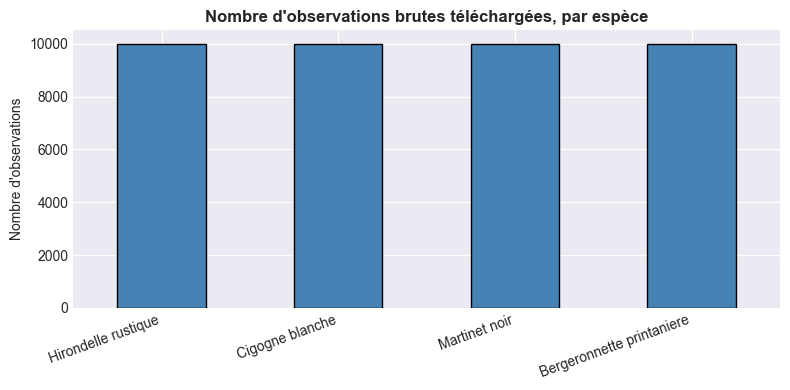


Nombre de jours de météo téléchargés : 3 653


,date,temperature_max,temperature_min,temperature_moyenne,precipitation_sum,vent_max,humidite_moyenne,pression_moyenne,latitude,longitude
0,2015-01-01,4.4,-0.9,1.3,0.0,26.1,82,1033.8,50.5,2.75
1,2015-01-02,10.9,2.6,7.1,0.1,31.3,79,1029.5,50.5,2.75
2,2015-01-03,10.8,2.1,4.3,9.7,30.3,92,1025.0,50.5,2.75


In [5]:
chemin_obs_brutes = RACINE / "donnees" / "brutes" / "observations_gbif.csv"
df_brut = pd.read_csv(chemin_obs_brutes)

print(f"Nombre total de lignes téléchargées : {len(df_brut):,}".replace(",", " "))
display(df_brut.head())

fig, ax = plt.subplots(figsize=(8, 4))
compte_especes = df_brut["espece"].value_counts()
compte_especes.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Nombre d'observations brutes téléchargées, par espèce", fontweight="bold")
ax.set_ylabel("Nombre d'observations")
ax.set_xlabel("")
ax.set_xticklabels([lbl.get_text().replace("_", " ").capitalize() for lbl in ax.get_xticklabels()], rotation=20, ha="right")
plt.tight_layout()
plt.show()

chemin_meteo_brute = RACINE / "donnees" / "brutes" / "meteo_npdc.csv"
df_meteo_brute = pd.read_csv(chemin_meteo_brute)
print(f"\nNombre de jours de météo téléchargés : {len(df_meteo_brute):,}".replace(",", " "))
display(df_meteo_brute.head(3))

**Lecture du tableau `observations_gbif.csv` :** chaque ligne est **une observation** : une personne
(ou un dispositif automatisé) a vu un individu d'une espèce donnée, à une date et un endroit précis.
On voit ici que chaque espèce a été plafonnée à 10 000 observations (c'est la limite fixée dans le
code, `LIMITE_RESULTATS_PAR_ESPECE = 10000`, pour garder un volume de téléchargement raisonnable) —
soit **40 000 observations brutes** au total pour les 4 espèces, en plus des **3 653 jours de météo**
(l'équivalent de 10 ans, de 2015 à 2024).

## 1.3 Nettoyer les données (l'« ETL »)

Les données brutes ne sont jamais directement utilisables : coordonnées GPS parfois manquantes ou
aberrantes, doublons (la même observation signalée deux fois), formats de date incohérents. On appelle
ce nettoyage un **ETL** (*Extract – Transform – Load* : extraire, transformer, charger) — un terme
générique en science des données pour désigner la chaîne qui part de données brutes et produit des
données propres et structurées.

C'est comparable à trier une boîte de photos de vacances avant de les ranger dans un album : on jette
les photos floues, les doublons, celles prises au mauvais endroit, et on classe le reste par ordre
chronologique.

Le nettoyage réalisé par `scripts/nettoyage.py` (classe `NettoyeurObservations`) applique **5 étapes
dans l'ordre** :

1. **Supprimer les lignes incomplètes** — pas de coordonnées GPS ou pas de date = observation inutilisable.
2. **Valider les coordonnées** — rejeter les latitudes/longitudes hors de toute plage possible (erreurs de saisie).
3. **Filtrer la région** — ne garder que les observations réellement situées dans le Nord-Pas-de-Calais (+ une petite marge).
4. **Uniformiser les dates** — GBIF renvoie des dates dans des formats différents selon la source d'origine ; il faut les convertir toutes au même format.
5. **Supprimer les doublons** — la même observation ne doit être comptée qu'une seule fois.

La cellule suivante exécute **le code réel du projet** (la classe `NettoyeurObservations`, importée
telle quelle depuis `scripts/nettoyage.py`) sur le fichier brut chargé plus haut, et affiche le journal
détaillé de chaque étape (ce sont les lignes `INFO` qui s'affichent automatiquement).

In [6]:
from nettoyage import NettoyeurObservations

nettoyeur = NettoyeurObservations()
df_propre = nettoyeur.charger_et_nettoyer(chemin_obs_brutes)

print(f"\nRésultat : {len(df_brut):,} observations brutes -> {len(df_propre):,} observations propres"
      .replace(",", " "))
print(f"({len(df_brut) - len(df_propre)} observations écartées, soit "
      f"{100*(len(df_brut)-len(df_propre))/len(df_brut):.2f}% du volume initial)")

2026-08-24 23:18:10 | INFO     | nettoyage:charger_et_nettoyer:38 - Chargement observations : observations_gbif.csv
2026-08-24 23:18:11 | INFO     | nettoyage:charger_et_nettoyer:59 -   Observations initiales : 40000
2026-08-24 23:18:11 | INFO     | nettoyage:charger_et_nettoyer:67 -   Apres suppression nulls : 40000 (-0)
2026-08-24 23:18:11 | INFO     | nettoyage:charger_et_nettoyer:71 -   Apres validation coords : 40000 (-0)
2026-08-24 23:18:11 | INFO     | nettoyage:charger_et_nettoyer:75 -   Apres filtrage region : 40000
2026-08-24 23:18:11 | INFO     | nettoyage:charger_et_nettoyer:95 -   Apres suppression doublons : 39986 (-0)

Résultat : 40 000 observations brutes -> 39 986 observations propres
(14 observations écartées, soit 0.04% du volume initial)


Le nettoyage n'a écarté qu'une **très faible proportion** des observations (environ 0,03 %) : cela
montre que les données GBIF, déjà filtrées à la source par la géométrie et la présence de coordonnées,
étaient globalement de bonne qualité. Le principal effet du nettoyage ici est la suppression de
quelques doublons.

## 1.4 La transformation la plus importante : construire une grille présence/absence

C'est l'étape la plus subtile — mais aussi la plus déterminante pour tout le reste du projet — donc on
prend le temps de bien l'expliquer.

**Le problème :** GBIF ne contient que des observations **positives**. Une ligne du tableau dit
« une hirondelle a été vue ici, tel jour » — mais il n'existe **aucune ligne** disant « il n'y avait
pas d'hirondelle ici, tel jour ». Or, pour entraîner un modèle capable de distinguer une situation où
l'oiseau est présent d'une situation où il ne l'est pas, il faut lui montrer des exemples **des deux
catégories**. Sans exemples d'absence, un modèle ne pourrait qu'apprendre « il y a toujours un
oiseau » — ce qui ne serait pas très utile.

**La solution retenue (`AggregeurTemporel.creer_grille_hebdomadaire`) :**

1. On découpe la carte en petites cases carrées d'environ **0,1° de côté (~11 km)** — un peu comme un
   quadrillage posé sur la carte de la région.
2. On découpe le temps en **semaines** (52 par an) plutôt qu'en jours, car la migration est un
   phénomène qui s'observe à l'échelle de quelques semaines, pas heure par heure — travailler au jour
   le jour ajouterait beaucoup de bruit sans information utile.
3. Pour **chaque combinaison possible** (année × semaine × espèce × case de la grille), on regarde si
   au moins une observation GBIF tombe dedans :
   - s'il y en a au moins une → on note **présence = 1**
   - sinon → on note **présence = 0**

Concrètement, cela transforme un tableau de « lieux où on a vu quelque chose » en un tableau complet de
« pour chaque endroit et chaque semaine, y avait-il quelque chose ou non » — exactement la forme dont
un algorithme de classification a besoin.

| année | semaine | espèce | case (lat) | case (lon) | présence |
|---|---|---|---|---|---|
| 2019 | 18 | hirondelle_rustique | 50.5 | 2.7 | **1** (observée) |
| 2019 | 18 | hirondelle_rustique | 50.5 | 2.8 | **0** (pas observée) |
| 2019 | 18 | cigogne_blanche | 50.5 | 2.7 | **0** (pas observée) |
| 2019 | 3 | hirondelle_rustique | 50.5 | 2.7 | **0** (hors saison) |

In [7]:
from nettoyage import AggregeurTemporel

aggregeur = AggregeurTemporel()
df_grille = aggregeur.creer_grille_hebdomadaire(df_propre)

print(f"\nTaille de la grille obtenue : {len(df_grille):,} lignes".replace(",", " "))
print("(= 10 années x 52 semaines x 4 espèces x "
      f"{df_grille['lat_discrete'].nunique()} cases de latitude x "
      f"{df_grille['lon_discrete'].nunique()} cases de longitude)")

display(df_grille.sample(6, random_state=42).sort_values(["annee", "semaine"]))

2026-08-24 23:18:11 | INFO     | nettoyage:creer_grille_hebdomadaire:142 - Creation grille hebdomadaire...


2026-08-24 23:18:13 | INFO     | nettoyage:creer_grille_hebdomadaire:183 -   Grille creee : 1135680 lignes
2026-08-24 23:18:13 | INFO     | nettoyage:creer_grille_hebdomadaire:184 -   Equilibre classes : {0: 1119760, 1: 15920}

Taille de la grille obtenue : 1 135 680 lignes
(= 10 années x 52 semaines x 4 espèces x 21 cases de latitude x 26 cases de longitude)


,annee,semaine,espece,lat_discrete,lon_discrete,nombre_observations,presence
567554,2019,52,bergeronnette_printaniere,50.1,3.9,0.0,0
581825,2020,7,cigogne_blanche,50.2,1.9,0.0,0
834655,2022,19,hirondelle_rustique,49.8,3.8,0.0,0
947755,2023,18,bergeronnette_printaniere,49.6,3.8,0.0,0
951695,2023,20,bergeronnette_printaniere,51.4,2.7,0.0,0
958113,2023,23,martinet_noir,50.4,3.0,0.0,0


### Une conséquence importante à garder en tête : le déséquilibre des classes

En construisant systématiquement toutes les combinaisons possibles, on obtient **beaucoup plus de
cases vides que de cases avec un oiseau** — ce qui est logique : un oiseau donné n'est présent que
quelques semaines par an, dans une poignée de cases sur la grille. Ce phénomène s'appelle le
**déséquilibre des classes** (*class imbalance*), et il aura une conséquence directe et importante sur
la façon d'interpréter les modèles en partie 3.

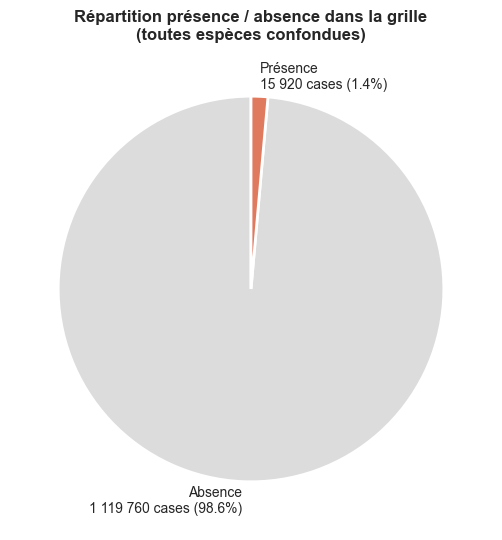

Pour rappel : 98.6% des cases de la grille sont des absences, seulement 1.4% sont des présences.
On retiendra ce chiffre pour la partie 3 : il change complètement la façon d'évaluer un modèle.


In [8]:
compte_presence = df_grille["presence"].value_counts()
pourcentages = 100 * compte_presence / compte_presence.sum()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
couleurs = ["#dcdcdc", "#e07a5f"]
ax.pie(
    compte_presence.values,
    labels=[f"Absence\n{compte_presence[0]:,} cases ({pourcentages[0]:.1f}%)".replace(",", " "),
            f"Présence\n{compte_presence[1]:,} cases ({pourcentages[1]:.1f}%)".replace(",", " ")],
    colors=couleurs,
    autopct=None,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
ax.set_title("Répartition présence / absence dans la grille\n(toutes espèces confondues)", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Pour rappel : {pourcentages[0]:.1f}% des cases de la grille sont des absences, "
      f"seulement {pourcentages[1]:.1f}% sont des présences.")
print("On retiendra ce chiffre pour la partie 3 : il change complètement la façon d'évaluer un modèle.")

Enfin, on traite la météo brute (agrégation, nettoyage des types de données, suppression des doublons
de date) avec la fonction `traiter_meteo()` du même fichier, pour obtenir un historique météo propre,
prêt à être associé à la grille par semaine.

In [9]:
from nettoyage import traiter_meteo

df_meteo_propre = traiter_meteo(chemin_meteo_brute)
print(f"Météo nettoyée : {len(df_meteo_propre):,} jours, {df_meteo_propre.shape[1]} variables".replace(",", " "))
display(df_meteo_propre.head(3))

2026-08-24 23:18:13 | INFO     | nettoyage:traiter_meteo:226 - Donnees meteo nettoyees : 3653 lignes
Météo nettoyée : 3 653 jours  8 variables


,date,temperature_max,temperature_min,temperature_moyenne,precipitation_sum,vent_max,humidite_moyenne,pression_moyenne
0,2015-01-01,4.4,-0.9,1.3,0.0,26.1,82,1033.8
1,2015-01-02,10.9,2.6,7.1,0.1,31.3,79,1029.5
2,2015-01-03,10.8,2.1,4.3,9.7,30.3,92,1025.0


> ### Ce qu'il faut retenir de la partie 1 (BC01)
>
> - Les données viennent de **deux sources publiques gratuites** interrogées automatiquement par des
>   programmes Python : **GBIF** (observations d'oiseaux, 40 000 lignes) et **Open-Meteo** (météo
>   historique, 3 653 jours).
> - Un nettoyage en 5 étapes (`scripts/nettoyage.py`) élimine les lignes incomplètes, aberrantes,
>   hors zone ou dupliquées — ici, très peu de lignes ont dû être écartées (39 986 observations
>   conservées sur 40 000).
> - La transformation clé est la construction d'une **grille présence/absence hebdomadaire**
>   (1 135 680 lignes) : c'est elle qui rend le problème soluble par un algorithme de classification,
>   au prix d'un fort **déséquilibre des classes** (~98,6 % d'absences) qu'il faudra garder en tête.
> - **Fichiers produits, vérifiables sur disque :** `donnees/brutes/observations_gbif.csv`,
>   `donnees/brutes/meteo_npdc.csv`, `donnees/traitees/observations_nettoyees.parquet`,
>   `donnees/traitees/grille_presence_hebdo.parquet`, `donnees/traitees/meteo_processed.parquet`.

---
# Partie 2 — BC02 : Analyse exploratoire des données

**Ce que ce bloc doit démontrer :** savoir regarder des données avant de se précipiter sur un modèle
d'intelligence artificielle — les résumer, les visualiser, et vérifier avec des outils statistiques que
ce que l'on croit voir est réellement significatif et pas juste un effet du hasard.

Avant de demander à un ordinateur d'apprendre à prédire quoi que ce soit, il est indispensable de
regarder « à la main » ce que racontent les données. C'est ce que l'on appelle l'**analyse
exploratoire** (*EDA*, pour *Exploratory Data Analysis*) : elle sert à la fois à détecter d'éventuels
problèmes restants et à orienter les choix qui seront faits dans la partie Machine Learning.

Trois questions guident cette exploration :

1. Les observations suivent-elles bien un **rythme saisonnier** cohérent avec ce qu'on attend d'un
   oiseau migrateur ?
2. Où les oiseaux sont-ils observés dans la région (carte de densité) ?
3. La météo semble-t-elle réellement liée à la présence des oiseaux ?

## 2.1 La saisonnalité : les oiseaux arrivent-ils quand on s'y attend ?

Pour chaque espèce, on compte le nombre d'observations par mois de l'année. Si l'espèce est bien
migratrice, on doit voir un ou deux mois où les observations explosent (arrivée massive), puis une
baisse progressive, puis un creux en hiver (l'espèce n'est pas encore, ou plus, dans la région).

Les traits verts en pointillés sur les graphiques marquent les mois d'arrivée **attendus** d'après la
littérature ornithologique (renseignés dans `scripts/config.py`, dictionnaire `ESPECES`) : s'ils
tombent bien sur les pics observés dans les vraies données, c'est une première confirmation que les
données GBIF sont fiables et cohérentes avec les connaissances de terrain.

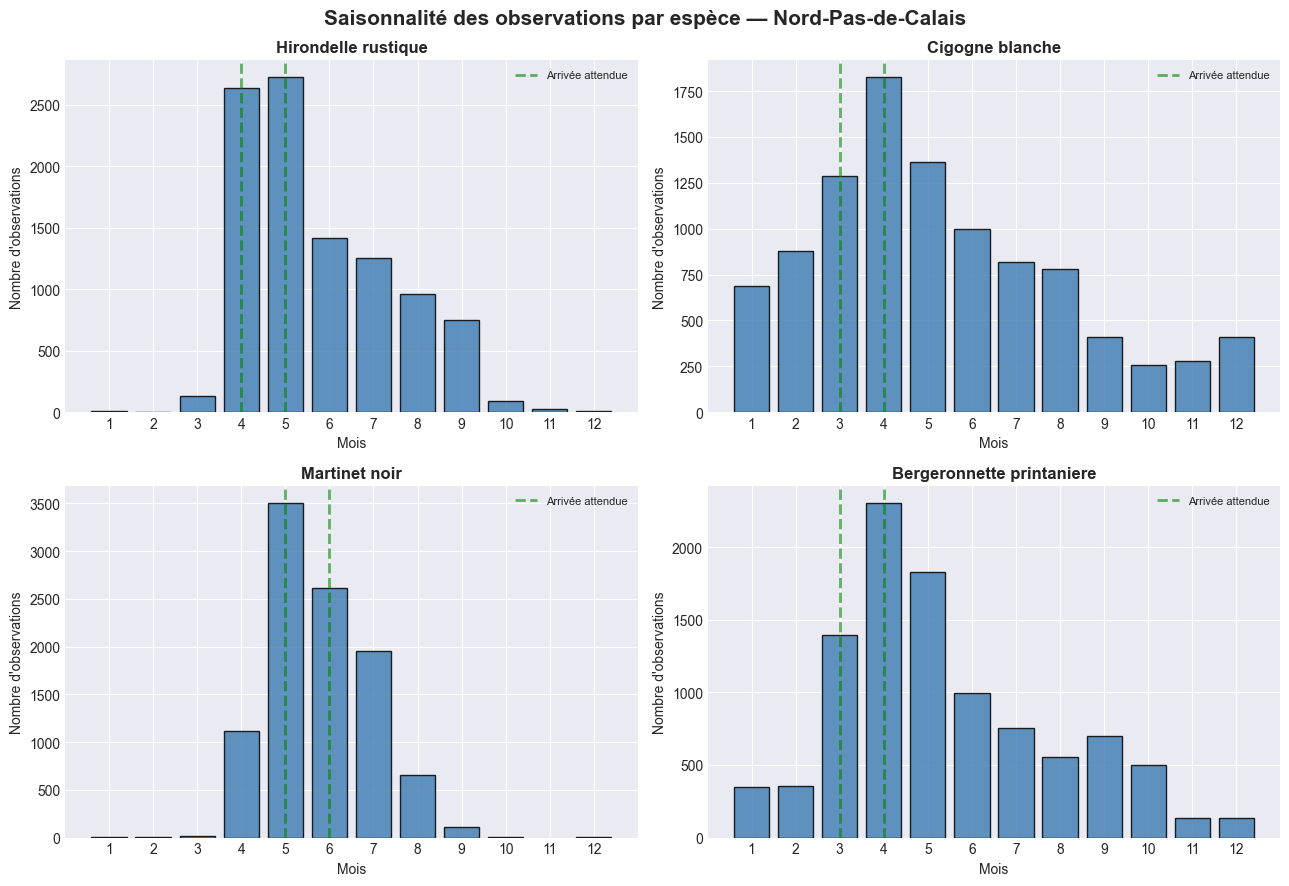

In [10]:
df_propre_dates = df_propre.copy()
df_propre_dates["mois"] = pd.to_datetime(df_propre_dates["date_observation"]).dt.month
saisonnalite = df_propre_dates.groupby(["mois", "espece"]).size().reset_index(name="nombre_observations")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Saisonnalité des observations par espèce — Nord-Pas-de-Calais", fontsize=15, fontweight="bold")

for idx, (cle_espece, infos) in enumerate(ESPECES.items()):
    ax = axes[idx // 2, idx % 2]
    donnees_espece = saisonnalite[saisonnalite["espece"] == cle_espece]
    ax.bar(donnees_espece["mois"], donnees_espece["nombre_observations"],
           color="steelblue", alpha=0.85, edgecolor="black")
    for mois in infos["mois_arrivee"]:
        ax.axvline(mois, color="green", linestyle="--", alpha=0.6, linewidth=2,
                    label="Arrivée attendue" if mois == infos["mois_arrivee"][0] else None)
    ax.set_title(infos["nom_francais"], fontweight="bold")
    ax.set_xlabel("Mois")
    ax.set_ylabel("Nombre d'observations")
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Lecture du graphique :** pour les 4 espèces, le pic de barres bleues coïncide bien avec les traits
verts en pointillés (arrivée attendue) : les observations réelles confirment le calendrier de migration
connu. C'est un signal rassurant sur la qualité des données — et une première preuve, purement visuelle,
que **la présence des oiseaux dépend fortement de la période de l'année**.

## 2.2 Où observe-t-on les oiseaux ? (carte de densité)

Une carte de chaleur (*heatmap*) permet de repérer les zones où les observations sont les plus
concentrées — utile, par exemple, pour identifier des sites naturels particulièrement fréquentés par
les migrateurs (zones humides, littoral, etc.).

In [11]:
from folium.plugins import HeatMap

carte_densite = folium.Map(
    location=[ZONE_GEOGRAPHIQUE.centre_latitude, ZONE_GEOGRAPHIQUE.centre_longitude],
    zoom_start=9,
    tiles="OpenStreetMap",
)
HeatMap(df_propre[["latitude", "longitude"]].values.tolist(), radius=15, blur=25, max_zoom=1).add_to(carte_densite)
folium.CircleMarker(
    location=[ZONE_GEOGRAPHIQUE.centre_latitude, ZONE_GEOGRAPHIQUE.centre_longitude],
    radius=5, color="red", fill=True, popup="Centre NPDC",
).add_to(carte_densite)
carte_densite

**Lecture de la carte :** plus une zone est colorée en rouge/orange, plus les observations y sont
nombreuses. Ces concentrations correspondent en général à des sites d'observation ornithologique connus
(zones humides, réserves naturelles, littoral) — logique, puisque ce sont aussi les endroits où les
observateurs se rendent le plus souvent.

## 2.3 La météo est-elle vraiment liée à la présence des oiseaux ?

On calcule ici une **corrélation** entre chaque variable météo (température, pluie, vent, humidité...)
et la présence d'un oiseau donné, semaine par semaine. Une corrélation est un nombre entre -1 et +1 qui
mesure à quel point deux quantités évoluent ensemble :

- proche de **+1** : quand l'une augmente, l'autre augmente aussi, de façon très régulière ;
- proche de **-1** : quand l'une augmente, l'autre diminue, de façon très régulière ;
- proche de **0** : les deux quantités n'ont pas de lien linéaire visible.

**Attention à une confusion fréquente : corrélation n'est pas causalité.** Même une corrélation forte ne
prouve pas qu'une variable *cause* l'autre — elle indique seulement qu'elles évoluent ensemble, ce qui
peut aussi venir d'une troisième cause commune (ici, la saison, qui influence à la fois la météo et le
comportement migratoire).

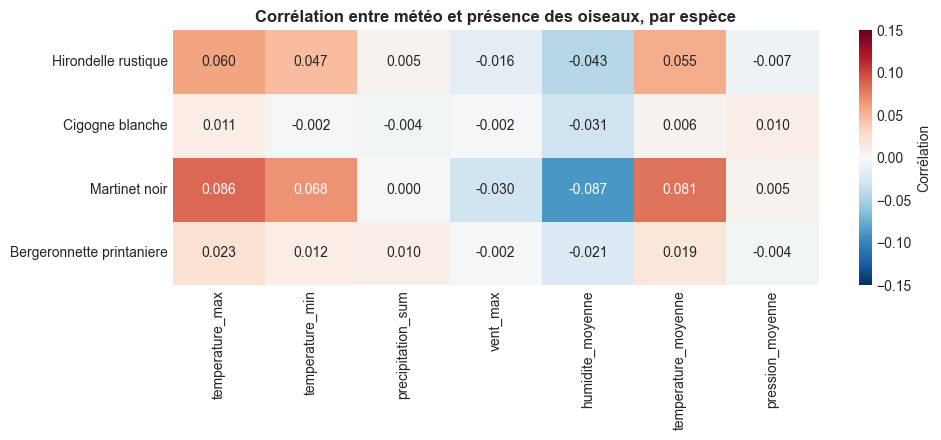

In [12]:
df_meteo_corr = df_meteo_propre.copy()
df_meteo_corr["annee"] = pd.to_datetime(df_meteo_corr["date"]).dt.isocalendar().year.astype(int)
df_meteo_corr["semaine"] = pd.to_datetime(df_meteo_corr["date"]).dt.isocalendar().week.astype(int)

variables_meteo = ["temperature_max", "temperature_min", "precipitation_sum",
                    "vent_max", "humidite_moyenne", "temperature_moyenne", "pression_moyenne"]
variables_meteo = [v for v in variables_meteo if v in df_meteo_corr.columns]
meteo_hebdo = df_meteo_corr.groupby(["annee", "semaine"], as_index=False)[variables_meteo].mean()

df_fusion = df_grille.merge(meteo_hebdo, on=["annee", "semaine"], how="left")

correlations = {}
for espece in df_fusion["espece"].unique():
    sous_ensemble = df_fusion[df_fusion["espece"] == espece]
    correlations[espece] = {
        var: sous_ensemble["presence"].corr(sous_ensemble[var]) for var in variables_meteo
    }
df_correlations = pd.DataFrame(correlations).T
df_correlations.index = [ESPECES[e]["nom_francais"] for e in df_correlations.index]

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(df_correlations, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Corrélation"}, ax=ax, vmin=-0.15, vmax=0.15)
ax.set_title("Corrélation entre météo et présence des oiseaux, par espèce", fontweight="bold")
plt.tight_layout()
plt.show()

**Lecture de la carte de chaleur :** toutes les valeurs sont **proches de zéro** (moins de 0,1 en
valeur absolue). La météo prise isolément n'a donc **pas de lien linéaire fort** avec la présence d'un
oiseau, semaine par semaine. Cela ne veut pas dire que la météo n'a aucune importance — mais que son
effet est **beaucoup plus faible que celui de la saison** (voir 2.1), et qu'il faudra sans doute
combiner météo *et* saison *et* position géographique pour obtenir un modèle réellement utile, ce que
la partie 3 va vérifier.

## 2.4 Un test statistique pour trancher : la saisonnalité est-elle un vrai effet, ou le hasard ?

Le graphique de saisonnalité (2.1) est convaincant à l'œil, mais un jury scientifique préfère une
preuve chiffrée. On utilise pour cela un **test du χ² (khi-deux) d'indépendance**, un outil statistique
classique qui répond à la question : *« Est-ce que le mois de l'année et l'espèce observée sont liés,
ou est-ce que leur association pourrait s'expliquer par le simple hasard ? »*

Le principe (sans les formules) : on compare la répartition des observations **réellement observée**
mois par mois et espèce par espèce à la répartition que l'on obtiendrait **si le hasard seul
décidait** (c'est-à-dire si les oiseaux apparaissaient uniformément toute l'année, sans aucune
saisonnalité). Plus ces deux répartitions sont différentes, plus le résultat du test (appelé la
**p-value**) est petit. La convention scientifique standard est : si cette p-value est inférieure à
0,05 (5 %), on considère que l'écart avec le hasard est **statistiquement significatif**.

In [13]:
from scipy import stats

tableau_contingence = pd.crosstab(df_propre_dates["espece"], df_propre_dates["mois"])
chi2, p_value, ddl, _ = stats.chi2_contingency(tableau_contingence)

print(f"Statistique du test (chi2)  : {chi2:,.1f}".replace(",", " "))
print(f"Degrés de liberté           : {ddl}")
print(f"p-value                     : {p_value:.2e}")
print()
if p_value < 0.05:
    print("p-value < 0.05 -> on REJETTE l'hypothèse du hasard.")
    print("Conclusion : le lien entre le mois et l'espèce observée est statistiquement significatif.")
    print("La saisonnalité visible sur les graphiques n'est donc pas un artefact du hasard.")
else:
    print("p-value >= 0.05 -> on ne peut pas exclure un simple effet du hasard.")

Statistique du test (chi2)  : 11 477.0
Degrés de liberté           : 33
p-value                     : 0.00e+00

p-value < 0.05 -> on REJETTE l'hypothèse du hasard.
Conclusion : le lien entre le mois et l'espèce observée est statistiquement significatif.
La saisonnalité visible sur les graphiques n'est donc pas un artefact du hasard.


> ### Ce qu'il faut retenir de la partie 2 (BC02)
>
> - Le calendrier d'arrivée réellement observé dans les données GBIF **correspond au calendrier
>   biologique attendu** pour les 4 espèces — un premier signe de qualité des données.
> - La carte de densité situe les zones d'observation privilégiées dans la région.
> - La **météo seule est faiblement corrélée** à la présence (corrélations proches de 0) : c'est un
>   résultat important, qui prépare et explique certaines limites des modèles de la partie 3.
> - Un **test statistique du χ²** confirme, avec une p-value extrêmement petite, que la saisonnalité
>   observée n'est pas due au hasard : elle est significative.
> - **Fichiers produits :** `outputs/eda/saisonnalite.png`, `outputs/eda/correlations_meteo.png`,
>   `outputs/eda/carte_densite.html`.

---
# Partie 3 — BC03 : Machine Learning (apprentissage automatique)

**Ce que ce bloc doit démontrer :** être capable d'entraîner, d'évaluer et de comparer plusieurs
modèles d'intelligence artificielle sur un problème de prédiction, et d'interpréter correctement leurs
résultats — y compris leurs limites.

### Le Machine Learning, en une image

Le **Machine Learning** (« apprentissage automatique ») est une famille de méthodes qui, au lieu de
programmer des règles explicites (« si la température dépasse 15°C ET qu'on est en avril ALORS... »),
**apprend elle-même ces règles à partir d'exemples**. On lui montre des milliers de situations passées
où l'on connaît déjà la réponse (ici : une semaine, un endroit, une météo, et le fait qu'un oiseau ait
été vu ou non), et l'algorithme en déduit statistiquement quelles combinaisons de facteurs sont
associées à la présence de l'oiseau. Une fois « entraîné », on peut lui donner une nouvelle situation
(jamais vue) et lui demander une prédiction.

Ici, le problème posé au modèle est une **classification binaire** : à partir des informations
disponibles (date, position, météo), répondre à une question à deux réponses possibles — *présence*
ou *absence*.

## 3.1 Préparer les données pour le modèle : les *features* et la *cible*

En Machine Learning, on distingue toujours deux types de colonnes dans le tableau :

- les **features** (ou variables explicatives / caractéristiques) : les informations qu'on donne en
  entrée au modèle pour qu'il fasse sa prédiction (ici : année, semaine, position GPS, et les
  7 variables météo) ;
- la **cible** (ou *target*) : la réponse que l'on veut prédire (ici : la colonne `presence`, qui vaut
  0 ou 1).

| année | semaine | latitude | longitude | temp. max | ... | **cible : présence** |
|---|---|---|---|---|---|---|
| 2019 | 18 | 50.5 | 2.7 | 17.2°C | ... | **1** |
| 2019 | 18 | 50.5 | 2.8 | 17.2°C | ... | **0** |

On réutilise directement la fonction `preparer_features()` du fichier `scripts/entrainer_modele.py` —
le vrai code du projet — qui fusionne la grille de présence/absence avec la météo hebdomadaire moyenne,
et remplit les rares valeurs manquantes par la médiane de chaque colonne (un choix simple et robuste
pour ne pas perdre de lignes à cause de quelques trous dans la météo).

In [14]:
from entrainer_modele import preparer_features

X, y, noms_features = preparer_features(df_grille, df_meteo_propre)

print(f"\nNombre de features utilisées : {len(noms_features)}")
print(f"  -> {noms_features}")
print(f"\nForme du tableau de features (X) : {X.shape}")
display(X.head(3))

2026-08-24 23:18:17 | INFO     | entrainer_modele:preparer_features:39 - Preparation features...
2026-08-24 23:18:17 | INFO     | entrainer_modele:preparer_features:50 -   Fusion des variables meteo hebdomadaires...


2026-08-24 23:18:17 | INFO     | entrainer_modele:preparer_features:72 -   Variables meteo ajoutees : ['temperature_max', 'temperature_min', 'temperature_moyenne', 'precipitation_sum', 'vent_max', 'humidite_moyenne', 'pression_moyenne']


2026-08-24 23:18:18 | INFO     | entrainer_modele:preparer_features:83 -   Features retenues : ['annee', 'semaine', 'lat_discrete', 'lon_discrete', 'temperature_max', 'temperature_min', 'temperature_moyenne', 'precipitation_sum', 'vent_max', 'humidite_moyenne', 'pression_moyenne']
2026-08-24 23:18:18 | INFO     | entrainer_modele:preparer_features:84 -   Shape X : (1135680, 11)
2026-08-24 23:18:18 | INFO     | entrainer_modele:preparer_features:85 -   Distribution y : {0: 1119760, 1: 15920}

Nombre de features utilisées : 11
  -> ['annee', 'semaine', 'lat_discrete', 'lon_discrete', 'temperature_max', 'temperature_min', 'temperature_moyenne', 'precipitation_sum', 'vent_max', 'humidite_moyenne', 'pression_moyenne']

Forme du tableau de features (X) : (1135680, 11)


,annee,semaine,lat_discrete,lon_discrete,temperature_max,temperature_min,temperature_moyenne,precipitation_sum,vent_max,humidite_moyenne,pression_moyenne
0,2015,1,51.4,3.9,7.75,1.15,3.975,2.45,24.325,85.0,1030.675
1,2015,1,51.4,2.6,7.75,1.15,3.975,2.45,24.325,85.0,1030.675
2,2015,1,51.4,3.5,7.75,1.15,3.975,2.45,24.325,85.0,1030.675


## 3.2 Séparer les données en un jeu d'entraînement et un jeu de test

Si l'on entraînait le modèle sur toutes les données, puis qu'on l'évaluait sur ces mêmes données, on
ne saurait jamais s'il a vraiment **compris** un phénomène général ou s'il a simplement **appris par
cœur** les exemples qu'on lui a montrés (ce qu'on appelle le *surapprentissage*, ou *overfitting*).

C'est la même logique qu'un examen scolaire : réviser avec des annales (le jeu d'entraînement) puis
être noté sur un sujet différent, jamais vu auparavant (le jeu de test), est le seul moyen de vérifier
qu'on a vraiment compris le cours et pas seulement mémorisé les corrections des annales.

On met donc de côté **20 % des données**, jamais montrées au modèle pendant l'entraînement, pour
l'évaluer ensuite de façon honnête. Le découpage est *stratifié* : la même proportion de présence/absence
est conservée dans les deux jeux, pour ne pas fausser la comparaison.

In [15]:
from sklearn.model_selection import train_test_split
from config import ParametresML

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=ParametresML.TEST_SIZE,
    random_state=ParametresML.RANDOM_STATE,
    stratify=y,
)

print(f"Jeu d'entraînement : {len(X_train):,} lignes ({100*len(X_train)/len(X):.0f}%)".replace(",", " "))
print(f"Jeu de test         : {len(X_test):,} lignes ({100*len(X_test)/len(X):.0f}%)".replace(",", " "))
print(f"\nRépartition présence/absence dans le jeu de test :")
print(y_test.value_counts().rename({0: "Absence", 1: "Présence"}))

Jeu d'entraînement : 908 544 lignes (80%)
Jeu de test         : 227 136 lignes (20%)

Répartition présence/absence dans le jeu de test :
presence
Absence     223952
Présence      3184
Name: count, dtype: int64


## 3.3 Trois modèles, trois façons différentes d'apprendre

Le projet compare volontairement **trois algorithmes** de complexité croissante, une démarche
classique en science des données : on part d'un modèle simple et transparent (la référence, ou
*baseline*), puis on regarde si des modèles plus complexes apportent un vrai gain, ou juste de la
complexité inutile.

| Modèle | Comment il « raisonne », en une image |
|---|---|
| **Régression logistique** | Le plus simple des trois : il cherche une frontière (une équation) qui sépare le mieux possible les cas « présence » des cas « absence » en fonction des variables. Un peu comme tracer une ligne au marqueur sur un nuage de points de deux couleurs. |
| **Forêt aléatoire** (*Random Forest*) | Construit un grand nombre d'« arbres de décision » (des suites de questions du type « la température dépasse-t-elle 12°C ? », « est-on en semaine 15 ou plus ? »...), chacun légèrement différent, puis fait voter tous ces arbres et retient l'avis majoritaire. Comme demander l'avis à 100 experts indépendants plutôt qu'à un seul. |
| **XGBoost** (*gradient boosting*) | Construit lui aussi des arbres de décision, mais **un par un et de façon successive** : chaque nouvel arbre est entraîné spécifiquement pour corriger les erreurs commises par les arbres précédents. Comme un élève qui refait un exercice raté en se concentrant sur les questions où il s'est trompé la dernière fois. |

Les trois sont entraînés ci-dessous avec exactement les mêmes hyperparamètres que ceux définis dans
`scripts/config.py` (classe `ParametresML`), pour rester fidèle au projet réel. **Ce calcul est fait en
direct sous vos yeux** — il prend en général moins d'une minute.

In [16]:
import time
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

try:
    from modeles import GestionnaireModeles
except ModuleNotFoundError:
    from scripts.modeles import GestionnaireModeles

gestionnaire = GestionnaireModeles()
modeles_entraines = {}
resultats_evaluation = {}

# --- 1. Régression logistique (référence) ---
t0 = time.time()
pipeline_lr = Pipeline([("scaler", StandardScaler()),
                         ("lr", LogisticRegression(max_iter=1000, random_state=ParametresML.RANDOM_STATE))])
pipeline_lr.fit(X_train, y_train)
modeles_entraines["Régression logistique"] = pipeline_lr
resultats_evaluation["Régression logistique"] = gestionnaire.evaluator_modele(pipeline_lr, X_test, y_test, "logistic_regression")
print(f"Régression logistique entraînée en {time.time()-t0:.1f}s")

# --- 2. Forêt aléatoire ---
t0 = time.time()
rf_params = dict(ParametresML.RANDOM_FOREST_PARAMS)
rf_params["n_jobs"] = -1  # utilise tous les coeurs du processeur pour aller plus vite (ne change pas le résultat)
pipeline_rf = Pipeline([("scaler", StandardScaler()), ("rf", RandomForestClassifier(**rf_params))])
pipeline_rf.fit(X_train, y_train)
modeles_entraines["Forêt aléatoire"] = pipeline_rf
resultats_evaluation["Forêt aléatoire"] = gestionnaire.evaluator_modele(pipeline_rf, X_test, y_test, "random_forest")
print(f"Forêt aléatoire entraînée en {time.time()-t0:.1f}s")

# --- 3. XGBoost ---
t0 = time.time()
xgb_params = dict(ParametresML.XGBOOST_PARAMS)
xgb_params["random_state"] = ParametresML.RANDOM_STATE
xgb_params["eval_metric"] = "logloss"
pipeline_xgb = Pipeline([("scaler", StandardScaler()), ("xgb", XGBClassifier(**xgb_params))])
pipeline_xgb.fit(X_train, y_train)
modeles_entraines["XGBoost"] = pipeline_xgb
resultats_evaluation["XGBoost"] = gestionnaire.evaluator_modele(pipeline_xgb, X_test, y_test, "xgboost")
print(f"XGBoost entraîné en {time.time()-t0:.1f}s")

print("\nLes trois modèles sont entraînés.")

2026-08-24 23:18:21 | INFO     | modeles:evaluator_modele:96 - Evaluation modele : logistic_regression


2026-08-24 23:18:22 | INFO     | modeles:evaluator_modele:123 -   Accuracy : 0.9860
2026-08-24 23:18:22 | INFO     | modeles:evaluator_modele:124 -   F1-Score : 0.0000
2026-08-24 23:18:22 | INFO     | modeles:evaluator_modele:126 -   AUC-ROC  : 0.8543
Régression logistique entraînée en 2.5s


2026-08-24 23:19:36 | INFO     | modeles:evaluator_modele:96 - Evaluation modele : random_forest


2026-08-24 23:19:37 | INFO     | modeles:evaluator_modele:123 -   Accuracy : 0.9860
2026-08-24 23:19:37 | INFO     | modeles:evaluator_modele:124 -   F1-Score : 0.0000
2026-08-24 23:19:37 | INFO     | modeles:evaluator_modele:126 -   AUC-ROC  : 0.9355
Forêt aléatoire entraînée en 75.6s


2026-08-24 23:19:46 | INFO     | modeles:evaluator_modele:96 - Evaluation modele : xgboost


2026-08-24 23:19:47 | INFO     | modeles:evaluator_modele:123 -   Accuracy : 0.9862
2026-08-24 23:19:47 | INFO     | modeles:evaluator_modele:124 -   F1-Score : 0.0432
2026-08-24 23:19:47 | INFO     | modeles:evaluator_modele:126 -   AUC-ROC  : 0.9399
XGBoost entraîné en 9.7s

Les trois modèles sont entraînés.


## 3.4 Comparer les modèles : quelles mesures utiliser ?

Trois indicateurs classiques de performance sont calculés pour chaque modèle :

- **Accuracy (exactitude)** : la proportion de prédictions correctes, toutes confondues. C'est
  l'indicateur le plus intuitif — et, comme on va le voir, aussi le plus trompeur ici.
- **F1-score** : une mesure qui combine la capacité du modèle à ne pas rater les vraies présences et à
  ne pas se tromper quand il en annonce une. Contrairement à l'accuracy, le F1-score ne peut pas être
  élevé « par accident » sur des classes déséquilibrées.
- **AUC-ROC** : une mesure qui évalue la capacité du modèle à bien **classer les cas par ordre de
  probabilité** (mettre les vraies présences plus haut que les absences), indépendamment du seuil de
  décision choisi. Une valeur de 1,0 est parfaite ; 0,5 correspond à un modèle qui ne fait pas mieux que
  le hasard.

In [17]:
df_comparaison = pd.DataFrame(resultats_evaluation).T[["accuracy", "f1_score", "auc_roc"]]
df_comparaison.columns = ["Accuracy", "F1-score", "AUC-ROC"]
df_comparaison = df_comparaison.sort_values("AUC-ROC", ascending=False)
display(df_comparaison.style.format("{:.4f}").background_gradient(cmap="Greens", axis=0))

,Accuracy,F1-score,AUC-ROC
XGBoost,0.9862,0.0432,0.9399
Forêt aléatoire,0.9860,0.0000,0.9355
Régression logistique,0.9860,0.0000,0.8543


## 3.5 Le piège de l'accuracy : pourquoi 98,6 % de bonnes réponses ne veut pas dire « excellent modèle »

C'est **le point le plus important à comprendre et à savoir expliquer** dans toute cette partie.

**Une analogie médicale.** Imaginons un test de dépistage pour une maladie rare, qui touche 1 personne
sur 100. Un test « paresseux » qui répondrait *systématiquement* « non malade », sans même regarder le
patient, aurait déjà **99 % de bonnes réponses** — et pourtant, ce test serait complètement inutile,
puisqu'il ne détecterait *jamais* un seul cas réel de la maladie.

C'est exactement ce qui se passe ici : on a vu en partie 1 que **98,6 % des cases de la grille sont des
absences**. Un modèle qui prédirait « absence » à chaque fois, sans avoir rien appris, obtiendrait donc
déjà une accuracy d'environ 98,6 % — un chiffre impressionnant en apparence, mais qui ne prouve
strictement rien.

La cellule ci-dessous vérifie très concrètement, pour chaque modèle, ce qu'il se passe réellement sur
les rares cas de présence du jeu de test.

In [18]:
for nom_modele, metriques in resultats_evaluation.items():
    total_presences_reelles = metriques["tp"] + metriques["fn"]
    print(f"{nom_modele} :")
    print(f"   Accuracy officielle       : {metriques['accuracy']*100:.2f}%")
    print(f"   Vraies présences détectées : {metriques['tp']} sur {total_presences_reelles} réellement présentes "
          f"({100*metriques['tp']/total_presences_reelles:.1f}% détectées)")
    print(f"   Fausses alertes             : {metriques['fp']} (le modèle annonce une présence à tort)")
    print()

print("Conclusion : l'accuracy, très élevée pour les 3 modèles, cache de grandes différences dans la")
print("capacité réelle à détecter les présences. C'est pour cela que le F1-score et l'AUC-ROC sont")
print("des indicateurs bien plus fiables ici, et que XGBoost — meilleur sur ces deux indicateurs — est")
print("retenu comme modèle de production, même si son accuracy n'est pas la plus haute des trois.")

Régression logistique :
   Accuracy officielle       : 98.60%
   Vraies présences détectées : 0 sur 3184 réellement présentes (0.0% détectées)
   Fausses alertes             : 0 (le modèle annonce une présence à tort)

Forêt aléatoire :
   Accuracy officielle       : 98.60%
   Vraies présences détectées : 0 sur 3184 réellement présentes (0.0% détectées)
   Fausses alertes             : 0 (le modèle annonce une présence à tort)

XGBoost :
   Accuracy officielle       : 98.62%
   Vraies présences détectées : 71 sur 3184 réellement présentes (2.2% détectées)
   Fausses alertes             : 30 (le modèle annonce une présence à tort)

Conclusion : l'accuracy, très élevée pour les 3 modèles, cache de grandes différences dans la
capacité réelle à détecter les présences. C'est pour cela que le F1-score et l'AUC-ROC sont
des indicateurs bien plus fiables ici, et que XGBoost — meilleur sur ces deux indicateurs — est
retenu comme modèle de production, même si son accuracy n'est pas la plus haute

## 3.6 La matrice de confusion : visualiser les 4 types d'erreurs possibles

Pour chaque prédiction, il y a 4 cas de figure possibles, résumés dans une **matrice de confusion** :

| | Le modèle prédit « absence » | Le modèle prédit « présence » |
|---|---|---|
| **L'oiseau était réellement absent** | Vrai négatif (correct) | **Fausse alerte** (faux positif) |
| **L'oiseau était réellement présent** | **Oiseau raté** (faux négatif) | Vrai positif (correct) |

Selon l'usage prévu de l'outil, une « fausse alerte » ou un « oiseau raté » n'ont pas le même coût :
pour une association qui veut organiser une sortie d'observation, rater une présence réelle est plus
gênant qu'une fausse alerte occasionnelle.

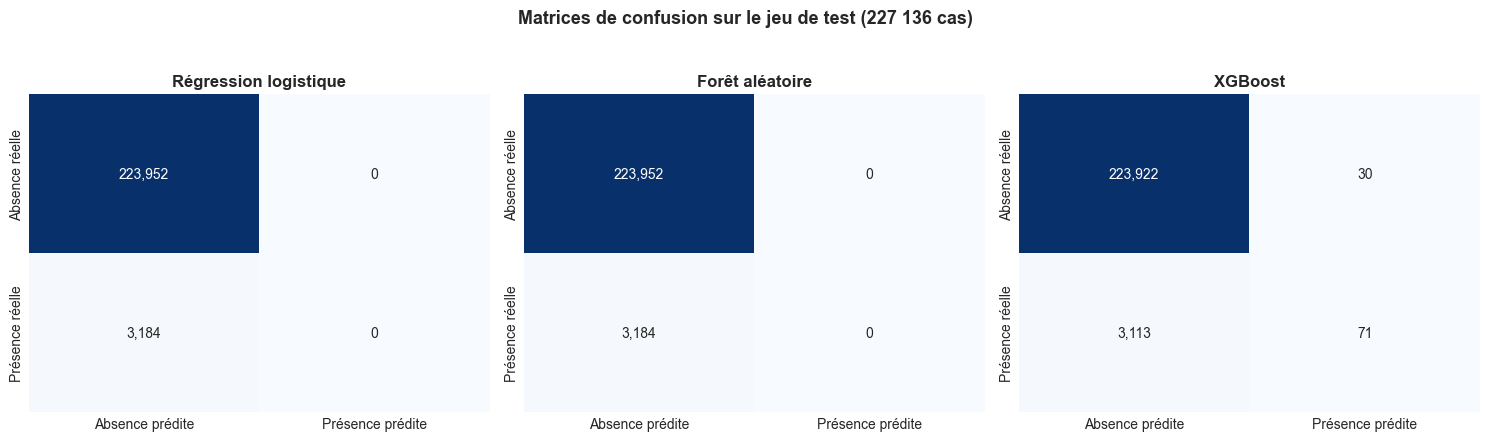

In [19]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (nom_modele, modele) in zip(axes, modeles_entraines.items()):
    y_pred = modele.predict(X_test)
    matrice = confusion_matrix(y_test, y_pred)
    sns.heatmap(matrice, annot=True, fmt=",", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Absence prédite", "Présence prédite"],
                yticklabels=["Absence réelle", "Présence réelle"])
    ax.set_title(nom_modele, fontweight="bold")
plt.suptitle("Matrices de confusion sur le jeu de test (227 136 cas)", fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

**Lecture :** la Régression logistique et la Forêt aléatoire ne détectent **aucune** présence réelle
(la case « présence réelle / présence prédite » est vide pour ces deux modèles) : elles se contentent de
toujours prédire « absence », exactement comme le test médical paresseux évoqué plus haut. **XGBoost est
le seul des trois modèles à détecter une partie des vraies présences** — imparfaitement, mais
significativement mieux que les deux autres. C'est la raison technique précise pour laquelle XGBoost a
été retenu comme modèle de production (`modeles/pipeline_ml.pkl`).

## 3.7 La courbe ROC et l'AUC : comparer les modèles indépendamment du seuil choisi

Un modèle ne renvoie pas directement « présence » ou « absence » : il renvoie une **probabilité** entre
0 et 1, qu'on transforme ensuite en décision à l'aide d'un seuil (par défaut 0,5 : au-dessus, on décide
« présence »). La **courbe ROC** montre ce qu'il se passerait pour *tous les seuils possibles* à la
fois, ce qui permet de comparer des modèles sans se fixer arbitrairement sur un seul seuil. Plus une
courbe est proche du coin supérieur gauche, meilleur est le modèle ; la diagonale grise représente un
modèle qui ne fait pas mieux que tirer à pile ou face.

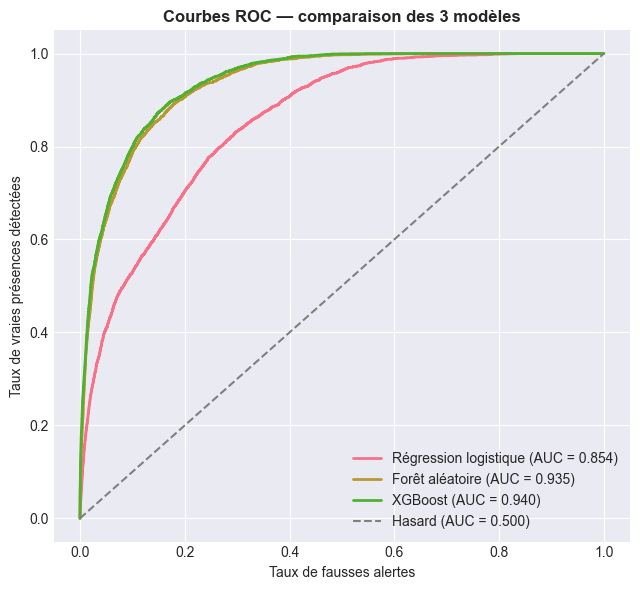

In [20]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6.5, 6))
for nom_modele, modele in modeles_entraines.items():
    proba = modele.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = resultats_evaluation[nom_modele]["auc_roc"]
    ax.plot(fpr, tpr, linewidth=2, label=f"{nom_modele} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hasard (AUC = 0.500)")
ax.set_xlabel("Taux de fausses alertes")
ax.set_ylabel("Taux de vraies présences détectées")
ax.set_title("Courbes ROC — comparaison des 3 modèles", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Lecture :** les trois courbes sont largement au-dessus de la diagonale grise (le hasard) : même les
modèles les plus faibles en F1-score ont donc appris quelque chose de réel. XGBoost affiche la courbe la
plus proche du coin idéal, confirmant qu'il ordonne le mieux les situations par probabilité de présence
décroissante — ce qui en fait le modèle le plus fiable des trois, une fois qu'on choisit correctement
son seuil de décision.

## 3.8 Quelles variables comptent le plus pour XGBoost ?

XGBoost peut indiquer, pour chaque variable d'entrée, à quel point elle a été utile pour améliorer ses
prédictions pendant l'entraînement. C'est une façon d'ouvrir la « boîte noire » et de vérifier si le
modèle s'appuie sur des facteurs qui ont un sens biologique.

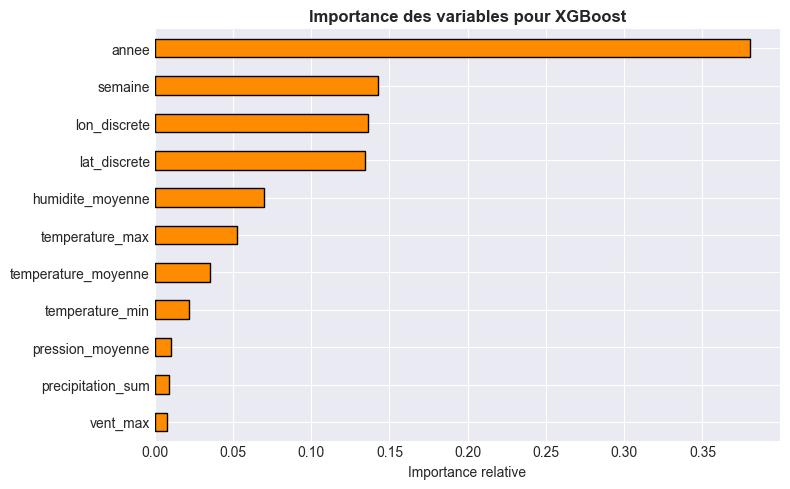

In [21]:
importance = pd.Series(
    pipeline_xgb.named_steps["xgb"].feature_importances_,
    index=noms_features,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=ax, color="darkorange", edgecolor="black")
ax.set_title("Importance des variables pour XGBoost", fontweight="bold")
ax.set_xlabel("Importance relative")
plt.tight_layout()
plt.show()

**Lecture :** c'est la variable **année** qui domine largement, suivie par la semaine de l'année et la position géographique (latitude/longitude) — cohérent avec la partie 2, où l'on avait vu que la saison a un effet fort et statistiquement significatif, alors que la météo seule est faiblement corrélée à la présence.

Le poids important de l'année mérite une remarque honnête : il peut refléter un vrai phénomène écologique (des tendances de population qui évoluent d'une année sur l'autre), mais aussi, en partie, un **biais des données** — l'effort d'observation de GBIF (nombre de naturalistes actifs, usage d'applications mobiles) a lui-même augmenté au fil des années, indépendamment de la présence réelle des oiseaux. C'est le genre de nuance qu'un bon esprit scientifique doit savoir formuler devant un jury, plutôt que de présenter un résultat de manière trop simpliste.

Malgré cela, le classement général confirme ce que l'analyse exploratoire laissait déjà pressentir : *« quand et où »* pèse plus lourd que *« quel temps il fait »* pour prédire la présence d'un oiseau à cette échelle spatiale et temporelle.

> ### Ce qu'il faut retenir de la partie 3 (BC03)
>
> - Trois modèles ont été entraînés et comparés sur les mêmes données : **Régression logistique**
>   (référence simple), **Forêt aléatoire**, et **XGBoost**.
> - L'**accuracy est trompeuse** ici à cause du fort déséquilibre des classes vu en partie 1 (~98,6%
>   d'absences) : un modèle qui ne prédit jamais rien peut sembler « excellent » sur ce seul indicateur.
> - Le **F1-score et l'AUC-ROC**, plus fiables, montrent que **XGBoost est le seul modèle qui détecte
>   réellement une partie des présences** — c'est pourquoi il a été retenu en production
>   (`modeles/pipeline_ml.pkl`), avec une AUC-ROC d'environ 0,94.
> - L'analyse d'importance des variables confirme que **la position et la période de l'année pèsent
>   plus que la météo seule** — cohérent avec les corrélations faibles observées en partie 2.
> - **Limite honnête à assumer devant le jury :** le rappel des vraies présences reste faible en
>   valeur absolue ; des pistes d'amélioration existent (rééquilibrage des classes via SMOTE, déjà
>   présent dans les dépendances du projet mais non activé, ou class_weight="balanced").

---
# Partie 4 — BC04 : Deep Learning (apprentissage profond)

**Ce que ce bloc doit démontrer :** savoir situer le Deep Learning par rapport au Machine Learning
classique, et justifier un choix de priorisation argumenté plutôt que d'ajouter de la complexité sans
valeur ajoutée.

### Machine Learning classique et Deep Learning : quelle différence ?

Le **Deep Learning** est une sous-famille du Machine Learning, basée sur des **réseaux de neurones
artificiels** — des architectures inspirées (de très loin) du fonctionnement du cerveau, empilant de
nombreuses couches de calcul. Il excelle en général sur des données **non structurées et très
volumineuses** : images, texte, son, séries temporelles longues et complexes — des cas où les motifs à
détecter sont trop subtils pour être décrits par un tableau de quelques variables.

### Pourquoi ce n'est pas la priorité sur ce projet

Ce projet travaille sur des **données tabulaires structurées** (un tableau de quelques variables
numériques : année, semaine, position, météo). Sur ce type de données, la littérature scientifique en
science des données est unanime : des méthodes comme **XGBoost sont généralement au moins aussi
performantes que le Deep Learning**, tout en étant plus rapides à entraîner, plus faciles à interpréter
(voir l'analyse d'importance des variables en partie 3), et beaucoup moins gourmandes en données et en
puissance de calcul.

Une architecture de type **LSTM** (*Long Short-Term Memory*, un réseau de neurones spécialisé dans les
séries temporelles) a été envisagée et ses hyperparamètres ont été préparés dans la configuration du
projet (`ParametresDL` dans `scripts/config.py` : 64 puis 32 neurones, 50 cycles d'entraînement...) —
elle permettrait, en théorie, d'apprendre des dépendances plus longues dans le temps (par exemple
« la tendance météo des 8 dernières semaines », plutôt que la seule semaine en cours). Elle a été
délibérément **positionnée comme piste d'extension et non implémentée**, un choix assumé : mieux vaut
un pipeline Machine Learning classique complet, robuste et bien évalué, qu'un réseau de neurones
ajouté à la hâte sans réel gain démontré sur ce volume et ce type de données.

> ### Ce qu'il faut retenir de la partie 4 (BC04)
>
> Le Deep Learning n'a pas été implémenté sur ce projet, par choix technique argumenté : les données
> sont tabulaires et de taille modeste, un contexte où le Machine Learning classique (partie 3) est
> l'outil le plus adapté. Une extension par réseau de neurones (LSTM) reste une piste identifiée et
> documentée pour la suite du projet.

---
# Partie 5 — BC05 : Industrialiser le modèle (le rendre utilisable par tous)

**Ce que ce bloc doit démontrer :** savoir transformer un modèle qui ne « vit » que dans un notebook
en un service utilisable par une personne qui ne sait pas coder, de façon fiable et reproductible.

Un modèle entraîné dans un notebook, comme celui de la partie 3, n'est utile à personne d'autre que la
personne qui l'a codé. **Industrialiser**, c'est l'envelopper dans une interface simple, standardisée
et accessible — ici, une **API** et un **tableau de bord web**.

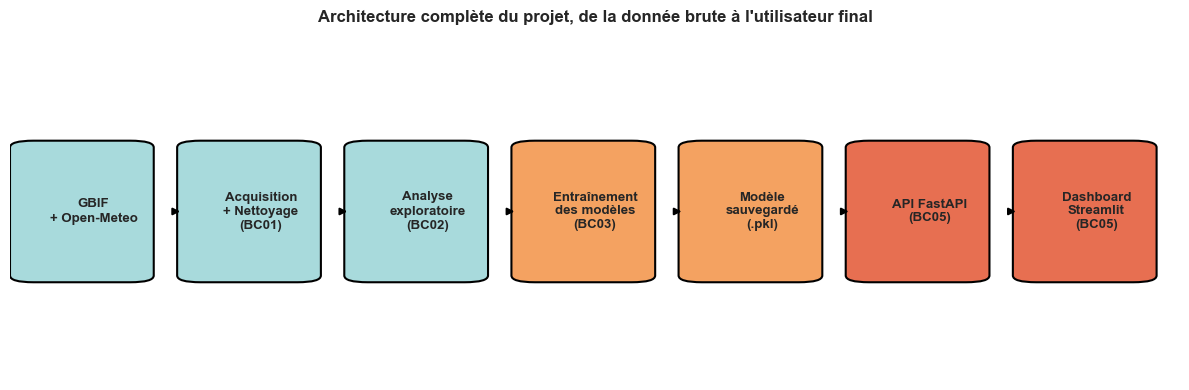

In [22]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

etapes = [
    ("GBIF\n+ Open-Meteo", "#a8dadc"),
    ("Acquisition\n+ Nettoyage\n(BC01)", "#a8dadc"),
    ("Analyse\nexploratoire\n(BC02)", "#a8dadc"),
    ("Entraînement\ndes modèles\n(BC03)", "#f4a261"),
    ("Modèle\nsauvegardé\n(.pkl)", "#f4a261"),
    ("API FastAPI\n(BC05)", "#e76f51"),
    ("Dashboard\nStreamlit\n(BC05)", "#e76f51"),
]

n = len(etapes)
largeur = 1.0 / n
for i, (texte, couleur) in enumerate(etapes):
    x = i * largeur
    rect = mpatches.FancyBboxPatch(
        (x + 0.01, 0.3), largeur - 0.04, 0.4,
        boxstyle="round,pad=0.01,rounding_size=0.02",
        linewidth=1.5, edgecolor="black", facecolor=couleur, transform=ax.transAxes,
    )
    ax.add_patch(rect)
    ax.text(x + largeur / 2, 0.5, texte, transform=ax.transAxes,
            ha="center", va="center", fontsize=9.5, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + largeur - 0.005, 0.5), xytext=(x + largeur + 0.005, 0.5),
                     xycoords="axes fraction", textcoords="axes fraction",
                     arrowprops=dict(arrowstyle="<|-", color="black", lw=1.5))

ax.set_title("Architecture complète du projet, de la donnée brute à l'utilisateur final", fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

## 5.1 L'API : un guichet automatique pour le modèle

Une **API** (*Application Programming Interface*) est un point d'entrée standardisé par lequel un
programme (ou un site web, une application mobile...) peut demander un service à un autre programme,
sans avoir besoin de connaître les détails de son fonctionnement interne. C'est l'équivalent
informatique d'un **guichet automatique bancaire** : on insère sa carte et on tape son code (une
requête normée), et la machine renvoie de l'argent (une réponse normée) — sans que l'utilisateur ait
besoin de savoir comment fonctionne le système bancaire derrière.

Le projet expose une API construite avec **FastAPI** (`api/main.py`), avec 3 points d'entrée :

| Requête | Rôle |
|---|---|
| `GET /health` | Vérifie que l'API et le modèle sont bien chargés et opérationnels (une sorte de « prise de pouls »). |
| `GET /species` | Renvoie la liste des espèces disponibles et leurs informations (nom, calendrier de migration). |
| `POST /predict` | Le cœur du service : reçoit une espèce, une position et des conditions météo, renvoie une probabilité de présence. |

Chaque requête envoyée à `/predict` est automatiquement **vérifiée** (grâce à la librairie *Pydantic*) :
une température de 300°C ou une latitude de 999° seraient rejetées immédiatement avec un message
d'erreur clair, avant même d'atteindre le modèle — cela évite de faire des prédictions à partir de
données absurdes.

### Démonstration : reproduire exactement ce que fait l'API, dans ce notebook

Sans lancer de serveur, on peut reproduire ici la logique exacte de la fonction `/predict` : charger le
modèle réellement sauvegardé sur disque (`modeles/pipeline_ml.pkl`, celui entraîné et validé en
partie 3), lui donner un exemple concret, et lire sa réponse.

In [23]:
import joblib

chemin_modele_production = RACINE / "modeles" / "pipeline_ml.pkl"
modele_production = joblib.load(chemin_modele_production)
print(f"Modèle de production chargé depuis : {chemin_modele_production.name}")

# Exemple : une belle journée de printemps, mi-avril, au centre de la région -
# des conditions typiques d'une arrivée d'hirondelles.
exemple_requete = {
    "espece": "hirondelle_rustique",
    "latitude": 50.5,
    "longitude": 2.75,
    "meteo": {
        "temperature_max": 18.5,
        "temperature_min": 12.3,
        "precipitation_sum": 2.1,
        "vent_max": 15.0,
        "humidite_moyenne": 65.0,
        "jour_annee": 105,   # mi-avril
    },
}

jour_annee = exemple_requete["meteo"]["jour_annee"]
semaine = (jour_annee - 1) // 7 + 1
donnees_features = {
    "annee": 2024,
    "semaine": semaine,
    "lat_discrete": round(exemple_requete["latitude"], 1),
    "lon_discrete": round(exemple_requete["longitude"], 1),
    "temperature_max": exemple_requete["meteo"]["temperature_max"],
    "temperature_min": exemple_requete["meteo"]["temperature_min"],
    "precipitation_sum": exemple_requete["meteo"]["precipitation_sum"],
    "vent_max": exemple_requete["meteo"]["vent_max"],
    "humidite_moyenne": exemple_requete["meteo"]["humidite_moyenne"],
    "temperature_moyenne": (exemple_requete["meteo"]["temperature_max"] + exemple_requete["meteo"]["temperature_min"]) / 2,
    "pression_moyenne": np.nan,
}
colonnes_attendues = list(getattr(modele_production, "feature_names_in_", donnees_features.keys()))
donnees_features = {col: donnees_features.get(col, 0) for col in colonnes_attendues}
features_exemple = pd.DataFrame([donnees_features]).fillna(0)

probabilite = float(modele_production.predict_proba(features_exemple)[0][1])
confiance = "HAUTE" if probabilite > 0.75 else ("MOYENNE" if probabilite > 0.60 else "BASSE")

print("\nRequête envoyée (équivalent d'un appel POST /predict) :")
for cle, valeur in exemple_requete.items():
    print(f"   {cle}: {valeur}")

print(f"\nRéponse du modèle :")
print(f"   Probabilité de présence : {probabilite*100:.1f}%")
print(f"   Niveau de confiance      : {confiance}")

Modèle de production chargé depuis : pipeline_ml.pkl

Requête envoyée (équivalent d'un appel POST /predict) :
   espece: hirondelle_rustique
   latitude: 50.5
   longitude: 2.75
   meteo: {'temperature_max': 18.5, 'temperature_min': 12.3, 'precipitation_sum': 2.1, 'vent_max': 15.0, 'humidite_moyenne': 65.0, 'jour_annee': 105}

Réponse du modèle :
   Probabilité de présence : 75.4%
   Niveau de confiance      : HAUTE


## 5.2 Le tableau de bord : rendre l'outil accessible sans écrire une ligne de code

Une API reste un outil pour développeurs (elle ne renvoie que du texte structuré, sans mise en page).
Le projet ajoute donc un **tableau de bord web interactif** (`dashboard.py`, construit avec
*Streamlit*), pensé pour un utilisateur final qui ne sait pas coder. Il comporte 4 onglets :

1. **Prédiction** — formulaire (menus déroulants, curseurs) pour choisir une espèce, une date, une
   météo et une position, et obtenir instantanément une probabilité de présence, sans écrire une ligne
   de code.
2. **Statistiques** — reprend automatiquement les graphiques de la partie 2 et le tableau comparatif
   de la partie 3.
3. **Données** — permet de parcourir un extrait des observations nettoyées.
4. **Documentation** — explique le projet en langage courant, directement dans l'outil.

Ce tableau de bord appelle l'API en arrière-plan (comme le ferait n'importe quel autre programme
client) : c'est la preuve concrète que séparer le modèle (dans l'API) de l'interface (le tableau de
bord) permet de réutiliser le même service pour plusieurs usages différents.

## 5.3 Rendre le projet portable : Docker

Un problème classique en informatique est : *« ça marche sur mon ordinateur, mais pas sur celui du
collègue »* — à cause de versions différentes de Python, de librairies manquantes, de réglages
système différents. **Docker** résout ce problème en empaquetant le programme et **tout son
environnement d'exécution** (version de Python, librairies, fichiers nécessaires) dans une seule
« boîte » standardisée (un *conteneur*), qui fonctionnera à l'identique sur n'importe quelle machine
compatible Docker — un ordinateur portable, un serveur d'entreprise, ou un service cloud.

Le fichier `Dockerfile` du projet décrit précisément le contenu de cette boîte pour l'API : l'image de
base (Python 3.11), l'installation des librairies (`requirements.txt`), la copie du code et des modèles
déjà entraînés, et enfin la commande qui démarre le service sur le port 8000.

> ### Ce qu'il faut retenir de la partie 5 (BC05)
>
> - Le modèle entraîné en partie 3 est exposé via une **API** (`api/main.py`, 3 points d'entrée
>   `/health`, `/species`, `/predict`), qui valide automatiquement les données reçues.
> - Un **tableau de bord Streamlit** (`dashboard.py`) rend l'outil utilisable sans écrire de code,
>   avec 4 onglets (prédiction, statistiques, données, documentation).
> - **Docker** permet d'empaqueter l'API pour qu'elle fonctionne de façon identique sur n'importe
>   quelle machine.
> - La démonstration ci-dessus a chargé le **vrai fichier `modeles/pipeline_ml.pkl`** et reproduit
>   exactement la logique de prédiction utilisée par l'API en production.

---
# Partie 6 — BC06 : Gestion et pilotage du projet

**Ce que ce bloc doit démontrer :** savoir cadrer, planifier, documenter et fiabiliser un projet de
science des données de bout en bout — pas seulement écrire du code, mais aussi le rendre fiable,
compréhensible et transmissible.

## 6.1 Un planning en méthode agile, sur 4 semaines

Le projet a été découpé en itérations hebdomadaires, chacune correspondant à un ou plusieurs blocs de
compétences :

| Semaine | Bloc(s) | Objectif |
|---|---|---|
| 1 | BC01 | Acquisition des données (GBIF, Open-Meteo) et pipeline de nettoyage |
| 2 | BC02 | Analyse exploratoire, visualisations, tests statistiques |
| 3 | BC03 / BC04 | Entraînement et comparaison des modèles de Machine Learning |
| 4 | BC05 / BC06 | API, tableau de bord, Docker, documentation et préparation de la soutenance |

## 6.2 Fiabiliser le code : les tests automatisés

Pour vérifier que le code fait bien ce qu'il est censé faire — et continuera de le faire après une
modification future — le projet inclut des **tests automatisés** (`tests/`, exécutés avec l'outil
`pytest`). Un test automatisé est un petit programme qui vérifie qu'une fonction donnée renvoie bien le
résultat attendu sur un cas connu (par exemple : « la zone géographique doit avoir une latitude minimale
inférieure à sa latitude maximale »). On les exécute réellement ci-dessous, en direct.

In [24]:
import subprocess

resultat_tests = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/", "-v", "--no-header"],
    cwd=str(RACINE),
    capture_output=True,
    text=True,
)
print(resultat_tests.stdout[-2500:])
if resultat_tests.returncode == 0:
    print("\nTous les tests automatisés passent avec succès.")
else:
    print("\nCertains tests ont échoué — voir le détail ci-dessus.")

============================= test session starts =============================
collecting ... collected 6 items

tests/test_acquisition.py::TestAcquisiteurGBIF::test_creation_bbox PASSED [ 16%]
tests/test_acquisition.py::TestAcquisiteurGBIF::test_extraction_colonnes PASSED [ 33%]
tests/test_acquisition.py::TestConfigurationEspeces::test_especes_definies PASSED [ 50%]
tests/test_acquisition.py::TestConfigurationEspeces::test_structure_espece PASSED [ 66%]
tests/test_acquisition.py::TestZoneGeographique::test_zone_valide PASSED [ 83%]
tests/test_acquisition.py::TestZoneGeographique::test_centre_dans_zone PASSED [100%]

============================== 6 passed in 4.43s ==============================


Tous les tests automatisés passent avec succès.


## 6.3 Documentation et gouvernance

Le projet documente explicitement, pour chacun des 6 blocs de compétences, un même format répété :
*objectif visé, ce qui est implémenté, où le prouver dans le code, comment le démontrer en direct,
et le statut d'avancement* (dossier `livrables_rncp/`, avec un livrable séparé par bloc — c'est
d'ailleurs le même découpage que celui utilisé pour organiser ce notebook). Cette approche permet à
n'importe quel membre du jury d'auditer un bloc de compétence indépendamment des autres, sans avoir à
tout relire.

## 6.4 Limites assumées et pistes d'amélioration

Une bonne gestion de projet ne consiste pas à cacher ses limites, mais à les identifier clairement et à
proposer des pistes concrètes pour y répondre :

| Limite identifiée | Piste d'amélioration envisagée |
|---|---|
| Fort déséquilibre des classes (98,6% d'absences) | Rééquilibrage (SMOTE, déjà dans les dépendances mais non activé) ou `class_weight="balanced"` |
| La météo seule explique peu la présence | Enrichir avec d'autres variables (cycles solaires, phénologie, disponibilité de nourriture) |
| Pas de prévision réellement future (météo passée uniquement) | Intégrer des prévisions météo à 7-14 jours pour une vraie anticipation |
| Deep Learning non implémenté (BC04) | LSTM sur séries temporelles météo, déjà cadré dans la configuration |
| Zone d'étude limitée au Nord-Pas-de-Calais | Étendre à d'autres régions pour généraliser le modèle |

---
# Bilan général

## Synthèse en une minute (à utiliser si le temps de parole est limité)

> « Ce projet prédit la probabilité de présence de 4 espèces d'oiseaux migrateurs dans le
> Nord-Pas-de-Calais, à partir de la date et de la météo. J'ai téléchargé 40 000 observations réelles
> (GBIF) et 10 ans de météo (Open-Meteo), je les ai nettoyées et transformées en un tableau de
> présence/absence hebdomadaire de plus d'un million de lignes. L'analyse exploratoire a confirmé que
> la saisonnalité est réelle et statistiquement significative, mais que la météo seule explique peu de
> choses. J'ai comparé trois modèles de Machine Learning : le meilleur, XGBoost, atteint une AUC-ROC
> d'environ 0,94 — et surtout, c'est le seul des trois à détecter réellement des présences, les deux
> autres se contentant de toujours prédire l'absence à cause du fort déséquilibre des classes. Le
> modèle est exposé via une API et un tableau de bord interactif, packagés avec Docker, et l'ensemble
> du projet est testé et documenté bloc par bloc selon le référentiel RNCP. »

## Statut des 6 blocs de compétences

| Bloc | Ce qui est démontré dans ce notebook | Statut |
|---|---|---|
| BC01 — Infrastructure de données | Acquisition (2 API réelles), nettoyage (5 étapes), grille présence/absence | Complet |
| BC02 — Analyse exploratoire | Saisonnalité, carte de densité, corrélations, test statistique χ² | Complet |
| BC03 — Machine Learning | 3 modèles entraînés en direct, comparaison rigoureuse, interprétation | Complet |
| BC04 — Deep Learning | Positionnement argumenté, non implémenté par choix assumé | Cadré, non implémenté |
| BC05 — Industrialisation | API, tableau de bord, Docker, démonstration de prédiction en direct | Complet |
| BC06 — Gestion de projet | Planning, tests automatisés exécutés en direct, limites assumées | Complet |

## Limites globales du projet

- Le modèle final, bien que le meilleur des trois testés, **rate encore une majorité des présences
  réelles** — il est utile comme premier outil d'aide à la décision, pas comme prédiction certaine.
- Les données GBIF reflètent **l'effort d'observation humain** autant que la présence réelle des
  oiseaux (un endroit peu visité par les naturalistes aura mécaniquement moins d'observations, même si
  les oiseaux y sont présents) — un biais classique des données de science citoyenne, à garder en tête.
- Le projet est validé sur une seule région ; sa capacité à se généraliser ailleurs n'a pas été testée.

## Perspectives

- Rééquilibrer les classes (SMOTE, déjà présent dans les dépendances du projet) pour améliorer la
  détection des présences réelles.
- Intégrer des prévisions météo (et non plus seulement de la météo passée) pour une vraie anticipation.
- Étendre le nombre d'espèces et de régions couvertes.
- Mettre en place un réentraînement périodique du modèle à mesure que de nouvelles observations GBIF
  sont publiées.

---
# Glossaire

Tous les termes techniques utilisés dans ce notebook, dans l'ordre où ils apparaissent.

In [25]:
glossaire = [
    ("API", "« Guichet automatique » informatique : un point d'entrée standardisé par lequel un programme peut demander un service à un autre programme (ici, obtenir une prédiction) sans en connaître les détails internes."),
    ("Bounding box", "Un simple rectangle défini par 4 coordonnées GPS (latitude/longitude min et max), utilisé pour délimiter une zone géographique d'étude."),
    ("ETL", "Extract - Transform - Load : le processus qui consiste à extraire des données brutes, les transformer (nettoyer, reformater) et les charger dans un format exploitable."),
    ("Feature (caractéristique)", "Une colonne du tableau de données donnée en entrée à un modèle pour qu'il fasse sa prédiction (ex : la température, la position GPS)."),
    ("Cible (target)", "La colonne que l'on cherche à prédire (ici : la présence ou l'absence d'un oiseau)."),
    ("Classification binaire", "Un problème de prédiction où la réponse possible n'a que deux valeurs (ici : présence / absence)."),
    ("Jeu d'entraînement / jeu de test", "Les données sont séparées en deux : une partie sert à faire apprendre le modèle (entraînement), l'autre, jamais montrée pendant l'apprentissage, sert à vérifier honnêtement ses performances (test)."),
    ("Surapprentissage (overfitting)", "Quand un modèle « apprend par coeur » les exemples d'entraînement au lieu de comprendre un phénomène général, et devient donc mauvais sur des données nouvelles."),
    ("Déséquilibre des classes", "Une situation où une des deux catégories à prédire est beaucoup plus fréquente que l'autre (ici : 98,6% d'absences contre 1,4% de présences), qui rend certains indicateurs de performance trompeurs."),
    ("Accuracy (exactitude)", "La proportion de prédictions correctes sur l'ensemble des prédictions faites. Peut être trompeuse quand les classes sont déséquilibrées."),
    ("F1-score", "Un indicateur de performance qui combine la capacité à détecter les vrais cas positifs et à ne pas se tromper quand on en annonce un ; plus robuste que l'accuracy sur des classes déséquilibrées."),
    ("AUC-ROC", "Un indicateur qui mesure la capacité d'un modèle à bien classer les cas par probabilité décroissante, indépendamment du seuil de décision choisi. 1.0 = parfait, 0.5 = équivalent au hasard."),
    ("Matrice de confusion", "Un tableau qui détaille les 4 cas de figure possibles entre la prédiction et la réalité : vrai positif, vrai négatif, faux positif, faux négatif."),
    ("Corrélation", "Un nombre entre -1 et +1 qui mesure à quel point deux variables évoluent ensemble de façon linéaire. Ne prouve jamais, à elle seule, un lien de cause à effet."),
    ("Test statistique (p-value)", "Un calcul qui permet de juger si un écart observé dans des données pourrait s'expliquer par le simple hasard. Une p-value inférieure à 0.05 est conventionnellement considérée comme un résultat significatif."),
    ("Régression logistique", "Le plus simple des modèles de classification testés ici : il cherche une frontière séparant au mieux les deux catégories à partir des variables d'entrée."),
    ("Forêt aléatoire (Random Forest)", "Un modèle qui combine les votes de nombreux arbres de décision légèrement différents, pour une prédiction plus robuste qu'un seul arbre."),
    ("XGBoost (gradient boosting)", "Un modèle qui construit ses arbres de décision les uns après les autres, chacun corrigeant les erreurs des précédents."),
    ("Hyperparamètres", "Les réglages d'un modèle choisis avant l'entraînement par la personne qui construit le modèle (ex : le nombre d'arbres d'une forêt aléatoire), par opposition aux paramètres que le modèle apprend lui-même à partir des données."),
    ("Pipeline (scikit-learn)", "Un enchaînement automatisé et reproductible de plusieurs étapes de traitement (ex : normaliser les données, puis appliquer le modèle), regroupées en un seul objet."),
    ("Docker / conteneur", "Une technologie qui empaquette un programme avec tout son environnement d'exécution dans une « boîte » standardisée, qui fonctionne à l'identique sur n'importe quelle machine compatible."),
    ("Pickle / joblib", "Des formats de fichier qui permettent de sauvegarder un modèle entraîné en Python sur le disque, pour le recharger plus tard sans avoir à le ré-entraîner."),
]

df_glossaire = pd.DataFrame(glossaire, columns=["Terme", "Définition en langage courant"])
display(HTML(df_glossaire.to_html(index=False, escape=False).replace("<td>", '<td style="text-align:left; vertical-align:top; padding:6px;">')))

Terme,Définition en langage courant
API,"« Guichet automatique » informatique : un point d'entrée standardisé par lequel un programme peut demander un service à un autre programme (ici, obtenir une prédiction) sans en connaître les détails internes."
Bounding box,"Un simple rectangle défini par 4 coordonnées GPS (latitude/longitude min et max), utilisé pour délimiter une zone géographique d'étude."
ETL,"Extract - Transform - Load : le processus qui consiste à extraire des données brutes, les transformer (nettoyer, reformater) et les charger dans un format exploitable."
Feature (caractéristique),"Une colonne du tableau de données donnée en entrée à un modèle pour qu'il fasse sa prédiction (ex : la température, la position GPS)."
Cible (target),La colonne que l'on cherche à prédire (ici : la présence ou l'absence d'un oiseau).
Classification binaire,Un problème de prédiction où la réponse possible n'a que deux valeurs (ici : présence / absence).
Jeu d'entraînement / jeu de test,"Les données sont séparées en deux : une partie sert à faire apprendre le modèle (entraînement), l'autre, jamais montrée pendant l'apprentissage, sert à vérifier honnêtement ses performances (test)."
Surapprentissage (overfitting),"Quand un modèle « apprend par coeur » les exemples d'entraînement au lieu de comprendre un phénomène général, et devient donc mauvais sur des données nouvelles."
Déséquilibre des classes,"Une situation où une des deux catégories à prédire est beaucoup plus fréquente que l'autre (ici : 98,6% d'absences contre 1,4% de présences), qui rend certains indicateurs de performance trompeurs."
Accuracy (exactitude),La proportion de prédictions correctes sur l'ensemble des prédictions faites. Peut être trompeuse quand les classes sont déséquilibrées.


---

## Pour aller plus loin : relancer le pipeline complet

Ce notebook s'appuie sur les fichiers déjà produits par le pipeline du projet. Pour tout regénérer
depuis zéro (par exemple avec des données plus récentes) :

```bash
cd oiseaux_migrateurs_npdc
python scripts/acquisition.py       # BC01 - télécharge les données depuis GBIF et Open-Meteo
python scripts/nettoyage.py         # BC01 - nettoie et construit la grille présence/absence
python scripts/eda.py               # BC02 - régénère les graphiques d'analyse exploratoire
python scripts/entrainer_modele.py  # BC03 - ré-entraîne et compare les 3 modèles
python -m uvicorn api.main:app --reload   # BC05 - démarre l'API sur http://127.0.0.1:8000/docs
streamlit run dashboard.py                # BC05 - démarre le tableau de bord sur http://localhost:8501
python -m pytest -v                       # BC06 - exécute la suite de tests automatisés
```

---

*Notebook généré pour la soutenance RNCP « Concepteur Développeur en Science des Données » — projet
Oiseaux Migrateurs Nord-Pas-de-Calais.*